In [28]:
import pandas as pd

# Import Data
data = pd.read_csv("individual joined 2016_2020 greater manchester.csv")

# Display the first few rows of the data
print(data.head())

  accident_reference  year casualty_severity sex_of_casualty  \
0          06A167327  2020            Slight          Female   
1          06A170518  2020            Slight            Male   
2          06A171184  2020            Slight            Male   
3          06A171671  2020            Slight            Male   
4          06A172407  2020            Slight            Male   

  age_band_of_casualty       casualty_home_area_type  \
0              26 - 35                    Urban area   
1              26 - 35  Data missing or out of range   
2              26 - 35                    Urban area   
3              26 - 35                    Urban area   
4              11 - 15                    Urban area   

            casualty_imd_decile  number_of_vehicles  number_of_casualties  \
0          More deprived 10-20%                   2                     1   
1  Data missing or out of range                   2                     1   
2          More deprived 20-30%                

In [29]:
# Descriptive Statistical Analysis - casualty_severity
print("Casualty Severity Descriptive Statistics:")
print(data['casualty_severity'].describe())
print("\n")

# Descriptive Statistical Analysis - age_band_of_casualty
print("Age Band of Casualty Descriptive Statistics:")
print(data['age_band_of_casualty'].describe())
print("\n")

# Descriptive Statistical Analysis - road_type
print("Road Type Descriptive Statistics:")
print(data['road_type'].describe())
print("\n")

# Descriptive Statistical Analysis - speed_limit
print("Speed Limit Descriptive Statistics:")
print(data['speed_limit'].describe())
print("\n")

# Descriptive Statistical Analysis - light_conditions
print("Light Conditions Descriptive Statistics:")
print(data['light_conditions'].describe())
print("\n")

# Descriptive Statistical Analysis - weather_conditions
print("Weather Conditions Descriptive Statistics:")
print(data['weather_conditions'].describe())
print("\n")

# Descriptive Statistical Analysis - road_surface_conditions
print("Road Surface Conditions Descriptive Statistics:")
print(data['road_surface_conditions'].describe())
print("\n")

# Descriptive Statistical Analysis - vehicle_manoeuvre
print("Vehicle Manoeuvre Descriptive Statistics:")
print(data['vehicle_manoeuvre'].describe())
print("\n")

# Descriptive Statistical Analysis - journey_purpose_of_driver
print("Journey Purpose of Driver Descriptive Statistics:")
print(data['journey_purpose_of_driver'].describe())


Casualty Severity Descriptive Statistics:
count       2421
unique         3
top       Slight
freq        1900
Name: casualty_severity, dtype: object


Age Band of Casualty Descriptive Statistics:
count        2421
unique         11
top       26 - 35
freq          607
Name: age_band_of_casualty, dtype: object


Road Type Descriptive Statistics:
count                   2421
unique                     6
top       Single carriageway
freq                    1980
Name: road_type, dtype: object


Speed Limit Descriptive Statistics:
count    2421.000000
mean       30.251962
std         4.588267
min        20.000000
25%        30.000000
50%        30.000000
75%        30.000000
max        60.000000
Name: speed_limit, dtype: float64


Light Conditions Descriptive Statistics:
count         2421
unique           5
top       Daylight
freq          1867
Name: light_conditions, dtype: object


Weather Conditions Descriptive Statistics:
count                   2421
unique                     9
top    

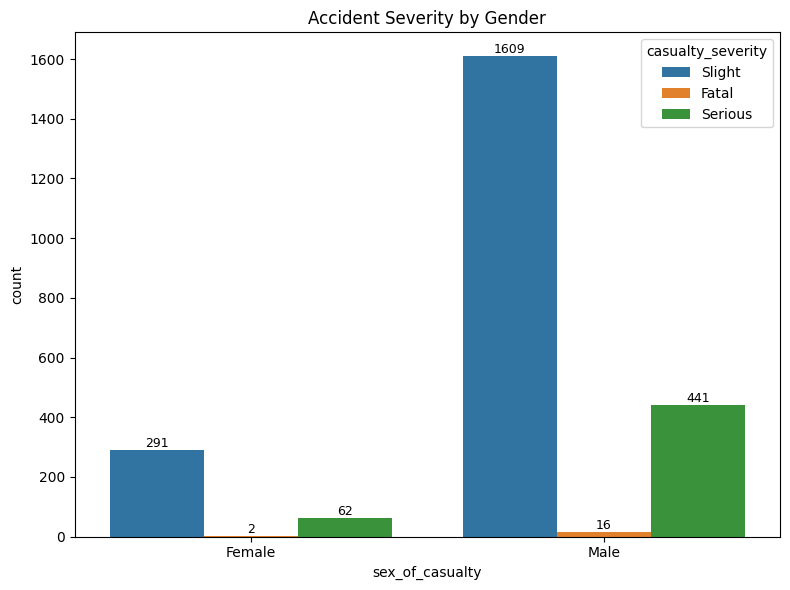

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import Data
df = pd.read_csv("individual joined 2016_2020 greater manchester.csv")

# Example 1: Gender vs Severity
plt.figure(figsize=(8,6))
ax=sns.countplot(data=df, x="sex_of_casualty", hue="casualty_severity")
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,  
            height,                       
            int(height),                  
            ha="center", va="bottom", fontsize=9
            )
plt.title("Accident Severity by Gender")
plt.ylabel("count")
plt.tight_layout()
plt.show()

C:\Users\18237\AppData\Local\Temp\ipykernel_19600\1205534762.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


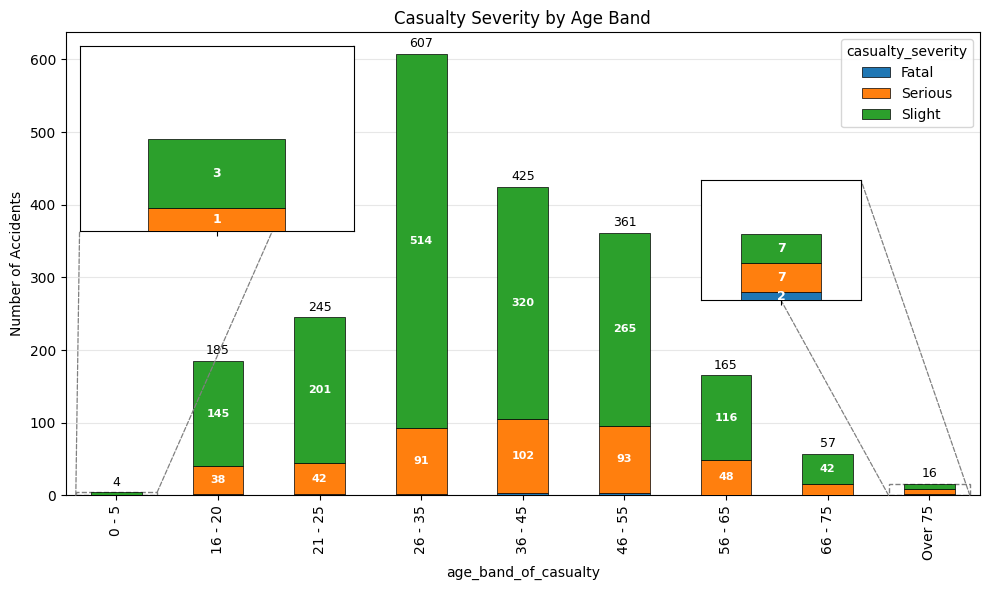

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch

# —— 1) Classification Order & Cross-tabulation ——
age_order = ["0 - 5","16 - 20","21 - 25",
             "26 - 35","36 - 45","46 - 55","56 - 65","66 - 75","Over 75"]
df["age_band_of_casualty"] = pd.Categorical(df["age_band_of_casualty"],
                                            categories=age_order, ordered=True)
age_severity = pd.crosstab(df["age_band_of_casualty"], df["casualty_severity"])

# —— 2) Main Image ——
fig, ax = plt.subplots(figsize=(10,6))
age_severity.plot(kind="bar", stacked=True, ax=ax, edgecolor="black",
                  linewidth=0.5, zorder=3, legend=True)
ax.grid(axis="y", zorder=0, alpha=0.3)
ax.set_title("Casualty Severity by Age Band")
ax.set_ylabel("Number of Accidents")
ax.set_xlabel("age_band_of_casualty")


#— A) Label each stacked section of the main graph 
def label_segments(ax, min_h=18):
    for p in ax.patches:
        h = p.get_height()
        if h >= min_h:
            ax.text(p.get_x()+p.get_width()/2,
                    p.get_y()+h/2,
                    int(h),
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
label_segments(ax)

#-- B) Mark the total number of each column on the main chart at the top
totals = age_severity.sum(axis=1).values
for i, t in enumerate(totals):
    ax.text(i, t + max(t*0.01, 5), # Raise the top a little bit higher
            int(t), ha="center", va="bottom", fontsize=9)


# -- 3) Utility Function: Add an inset that only displays numerical annotations and properly connect them --
def add_inset(ax, data, label, loc="upper left",
              width="30%", height="40%", borderpad=1,
              connect_corners=("bl","tl")):
    """
    connect_corners：Select the pairing of the main image rectangle corner and the inset corner
Corner name values: 'bl', 'tl', 'br', 'tr'
For example, ('bl','tl') indicates that the bottom-left corner of the main image rectangle is connected to the top-left corner of the inset.
    """
    # draw inset
    sub = data.loc[[label]]
    axins = inset_axes(ax, width=width, height=height, loc=loc, borderpad=borderpad)
    sub.plot(kind="bar", stacked=True, ax=axins, legend=False,
             edgecolor="black", linewidth=0.5, zorder=3)

   # Set the range of y
    ymax = max(8, float(sub.sum(axis=1).max()) * 1.8)
    axins.set_ylim(0, ymax)

   # Remove the axis elements and only retain the numerical labels
    axins.set_title(""); axins.set_xlabel(""); axins.set_ylabel("")
    axins.set_yticks([]); axins.tick_params(left=False, labelleft=False, labelbottom=False)

   # Numerical Annotation (Centered, White Text)
    for p in axins.patches:
        h = p.get_height()
        if h > 0:
            axins.text(p.get_x()+p.get_width()/2, p.get_y()+h/2, int(h),
                       ha="center", va="center", fontsize=9, color="white", fontweight="bold")

    # Highlight the column on the main image
    idx = data.index.get_loc(label)
    barw = 0.8
    total = float(sub.sum(axis=1).iloc[0])
    rect = Rectangle((idx - barw/2, 0), barw, total,
                     fill=False, linestyle="--", linewidth=1, edgecolor="gray")
    ax.add_patch(rect)

   # —— Precisely connect using ConnectionPatch ——
   # Coordinates (data coordinates) of the main figure's rectangular corners
    corners_ax = {
        "bl": (rect.get_x(),                      rect.get_y()),
        "tl": (rect.get_x(),                      rect.get_y()+rect.get_height()),
        "br": (rect.get_x()+rect.get_width(),     rect.get_y()),
        "tr": (rect.get_x()+rect.get_width(),     rect.get_y()+rect.get_height()),
    }
    # inset corner (Axes coordinate 0–1)
    corners_ins = {
        "bl": (0.0, 0.0), "tl": (0.0, 1.0),
        "br": (1.0, 0.0), "tr": (1.0, 1.0),
    }

    # Draw two lines: corresponding to two angles
    a1, a2 = connect_corners  
    b1, b2 = connect_corners  
    for A, B in [(a1, b1), ({"bl":"tr","tl":"br","br":"tl","tr":"bl"}[a1],
                             {"bl":"tr","tl":"br","br":"tl","tr":"bl"}[b1])]:
        con = ConnectionPatch(xyA=corners_ax[A], coordsA=ax.transData,
                              xyB=corners_ins[B], coordsB=axins.transAxes,
                              linestyle="--", color="gray", lw=0.9, zorder=4, clip_on=False)
        ax.add_artist(con)

    return axins

# —— 4) Add two insets ——
# Top-left corner: 0–5, connect from the bottom-left of the main figure rectangle to the top-left of the inset (without crossing)
add_inset(ax, age_severity, "0 - 5", loc="upper left", connect_corners=("bl","tl"))

sub = age_severity.loc[["Over 75"]]
axins2 = inset_axes(
    ax,
    width=1.6, height=1.2,           
    loc="upper right",
    bbox_to_anchor=(0.87, 0.68),   
    bbox_transform=ax.transAxes,
    borderpad=0
)
sub.plot(kind="bar", stacked=True, ax=axins2, legend=False,
         edgecolor="black", linewidth=0.5, zorder=3)

# Y-axis range
ymax = max(8, float(sub.sum(axis=1).max()) * 1.8)
axins2.set_ylim(0, ymax)

# Remove the axis elements
axins2.set_title(""); axins2.set_xlabel(""); axins2.set_ylabel("")
axins2.set_yticks([]); axins2.tick_params(left=False, labelleft=False, labelbottom=False)

# Numerical Annotation
for p in axins2.patches:
    h = p.get_height()
    if h > 0:
        axins2.text(p.get_x()+p.get_width()/2, p.get_y()+h/2,
                    int(h), ha="center", va="center", fontsize=9,
                    color="white", fontweight="bold")

# Select the column marked "Over 75" on the main image
idx = age_severity.index.get_loc("Over 75")
barw = 0.8
total = float(sub.sum(axis=1).iloc[0])
rect = Rectangle((idx - barw/2, 0), barw, total,
                 fill=False, linestyle="--", linewidth=1, edgecolor="gray")
ax.add_patch(rect)

# —— Connect the main graph rectangle to the inset using ConnectionPatch ——
corners_ax = {
    "bl": (rect.get_x(), rect.get_y()),
    "tl": (rect.get_x(), rect.get_y()+rect.get_height()),
    "br": (rect.get_x()+rect.get_width(), rect.get_y()),
    "tr": (rect.get_x()+rect.get_width(), rect.get_y()+rect.get_height())
}
corners_ins = {"bl": (0,0), "tl": (0,1), "br": (1,0), "tr": (1,1)}

# Main image rectangle lower left corner
pt_left_bottom = corners_ax["bl"]

# Main image rectangle lower right corner
pt_right_bottom = corners_ax["br"]

# Middle point at the bottom of the inset (Axes coordinates)
pt_inset_bottom_mid = (0.5, 0.0)

# inset - top right corner (Axes coordinates)
pt_inset_tr = corners_ins["tr"]

# Connection: Bottom Left -> Middle Point of the Inset
con1 = ConnectionPatch(
    xyA=pt_left_bottom, coordsA=ax.transData,
    xyB=pt_inset_bottom_mid, coordsB=axins2.transAxes,
    linestyle="--", color="gray", lw=0.9, zorder=4, clip_on=False
)
ax.add_artist(con1)

# Connection: Bottom right -> Top right of the Inset
con2 = ConnectionPatch(
    xyA=pt_right_bottom, coordsA=ax.transData,
    xyB=pt_inset_tr, coordsB=axins2.transAxes,
    linestyle="--", color="gray", lw=0.9, zorder=4, clip_on=False
)
ax.add_artist(con2)




plt.tight_layout()
plt.show()


C:\Users\18237\AppData\Local\Temp\ipykernel_19600\417045424.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["hour"] = pd.to_datetime(df["time"], errors="coerce").dt.hour


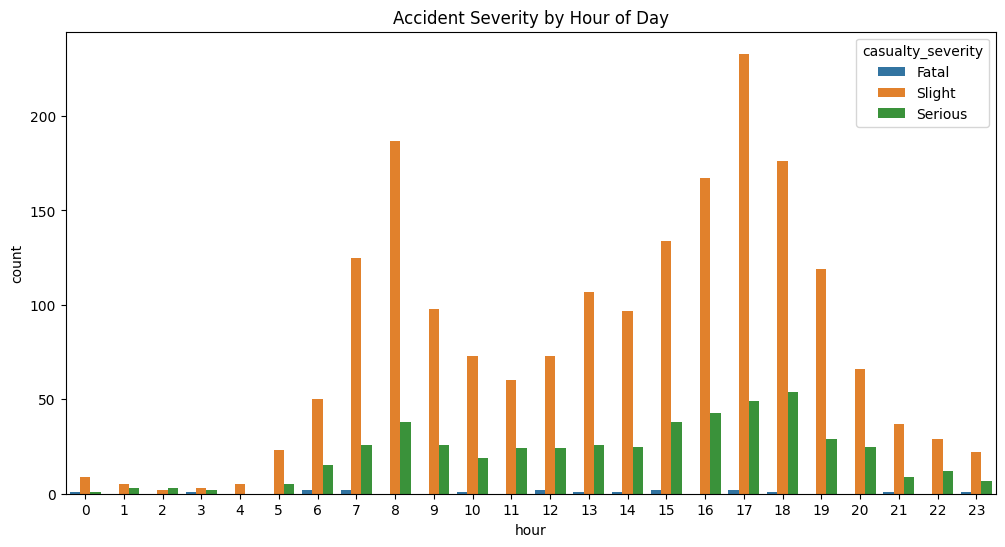

In [32]:
# Example 3: Time Period (by Hour) vs Severity
df["hour"] = pd.to_datetime(df["time"], errors="coerce").dt.hour
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="hour", hue="casualty_severity")
plt.title("Accident Severity by Hour of Day")
plt.show()

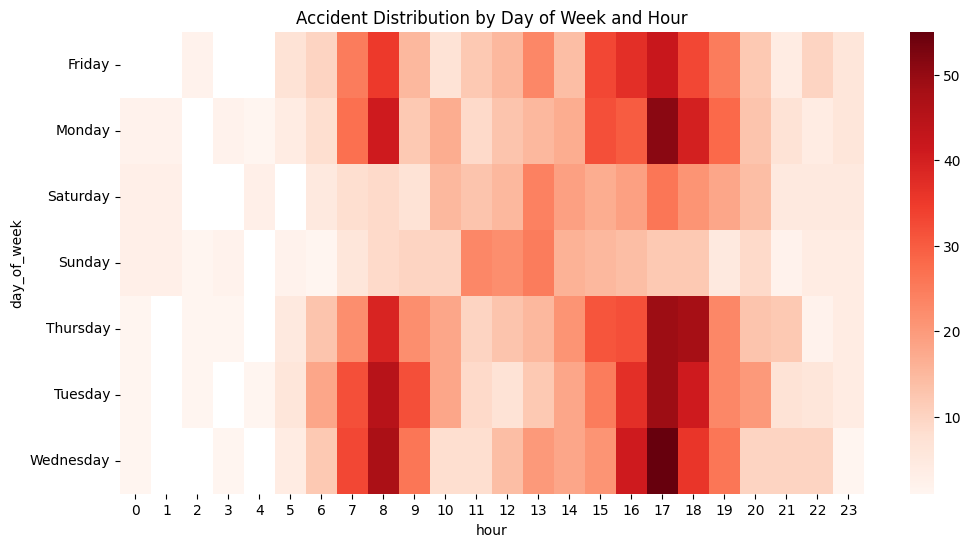

In [33]:
# Example 4: Heatmap - Weekday vs Time
pivot = df.pivot_table(index="day_of_week", columns="hour", values="casualty_severity", aggfunc="count")
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Reds")
plt.title("Accident Distribution by Day of Week and Hour")
plt.show()

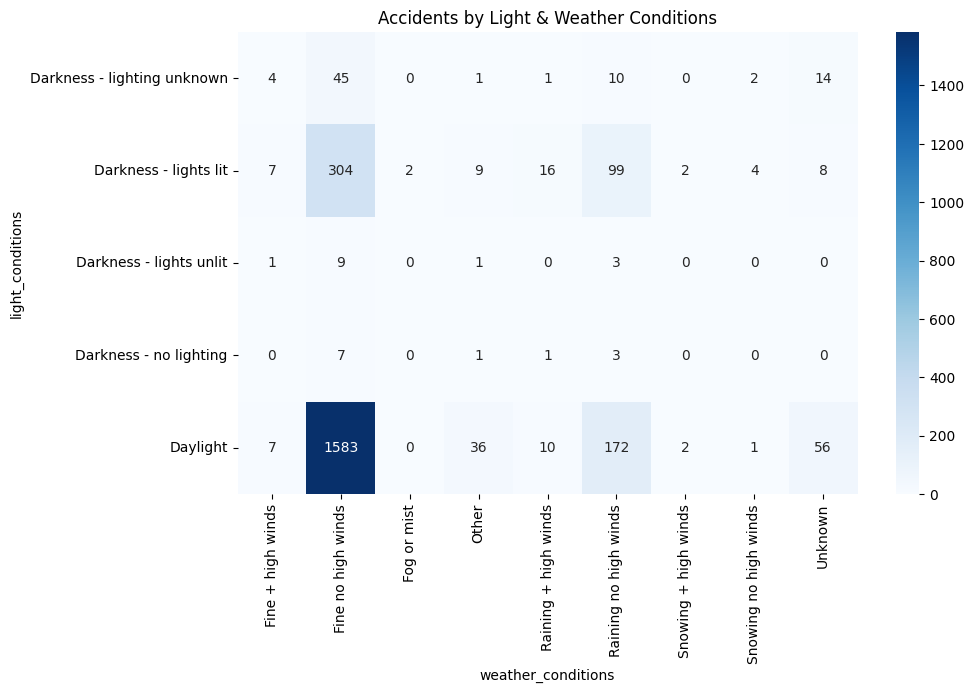

In [34]:
# 5. Lighting vs Weather (Heat Map)
light_weather = pd.crosstab(df["light_conditions"], df["weather_conditions"])
plt.figure(figsize=(10,6))
sns.heatmap(light_weather, cmap="Blues", annot=True, fmt="d")
plt.title("Accidents by Light & Weather Conditions")
plt.show()

C:\Users\18237\AppData\Local\Temp\ipykernel_19600\2862251105.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


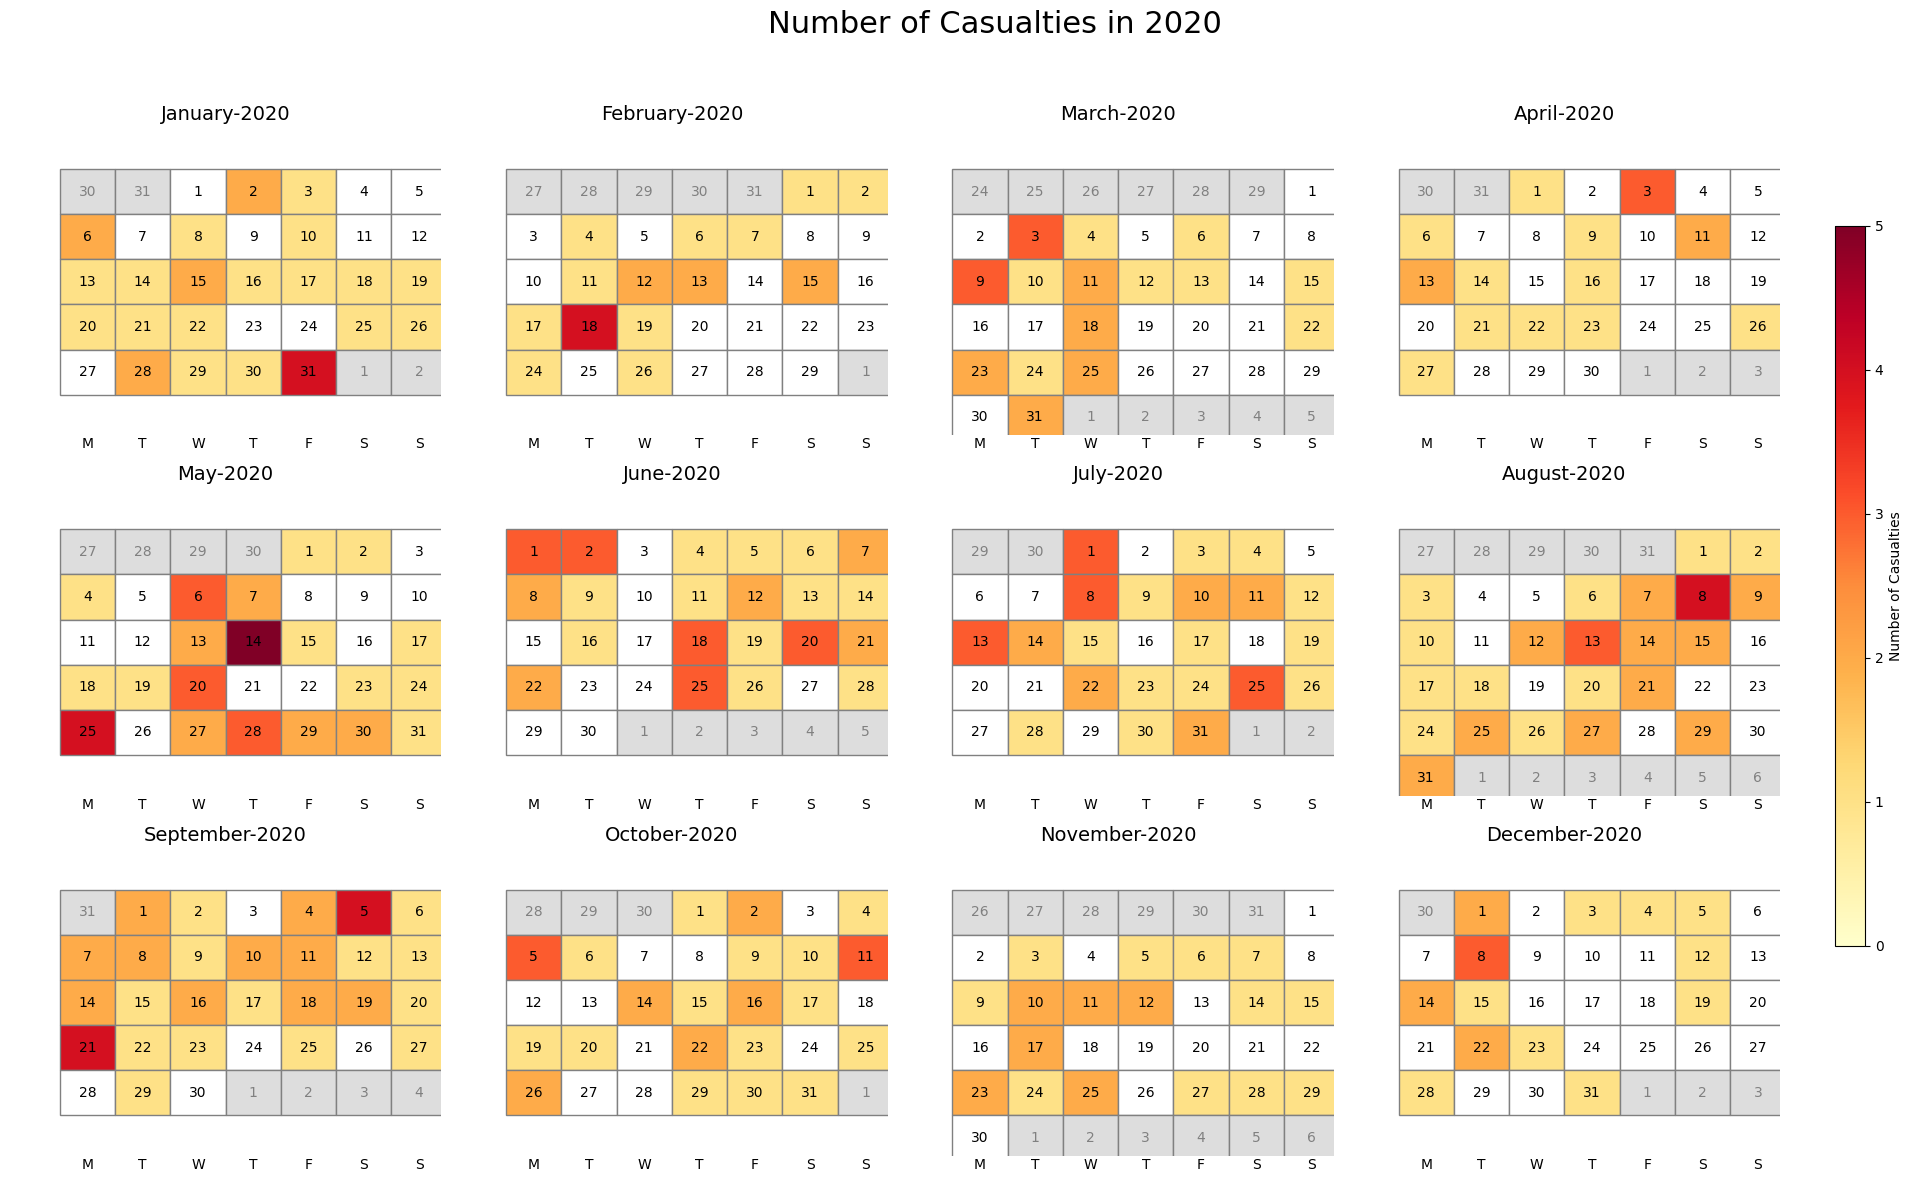

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# ====== Data Preparation ======
df = pd.read_csv('individual model_data 2016_2020 greater manchester.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date_only'] = df['date'].dt.date

# Select Year
year = 2020
df = df[pd.to_datetime(df['date_only']).dt.year == year]
daily_counts = df.groupby('date_only')['number_of_casualties'].sum()

# Create a complete date range
date_range = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31')
daily = pd.DataFrame({'date': date_range})
daily['number_of_casualties'] = daily['date'].dt.date.map(daily_counts).fillna(0).astype(int)

# ====== draw ======
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle(f'Number of Casualties in {year}', fontsize=22)

for month in range(1, 13):
    ax = axes[(month - 1) // 4, (month - 1) % 4]
    ax.set_title(calendar.month_name[month] + f'-{year}', fontsize=14)
    ax.axis('off')

   # Obtain the complete display range for this month (including the padding for the previous month and the next month)
    first_day = pd.Timestamp(year, month, 1)
    last_day = pd.Timestamp(year, month, calendar.monthrange(year, month)[1])
    start_date = first_day - pd.Timedelta(days=first_day.weekday())
    end_date = last_day + pd.Timedelta(days=6 - last_day.weekday())

    month_range = pd.date_range(start=start_date, end=end_date)

    for date in month_range:
        day = date.day
        weekday = date.weekday()
        week = (date - start_date).days // 7

        in_current_month = (date.month == month)
        casualties = daily_counts.get(date.date(), 0)

        # Color Settings
        color = (
            plt.cm.YlOrRd(casualties / 5)
            if casualties > 0 and in_current_month else
            ('white' if in_current_month else '#dddddd')
        )


        # Draw Grids
        rect = plt.Rectangle((weekday, week), 1, 1, color=color, ec='gray')
        ax.add_patch(rect)



        # Center display of the "number" digit
        text_color = 'black' if in_current_month else 'gray'
        ax.text(weekday + 0.5, week + 0.5, f"{day}",
                ha='center', va='center', fontsize=10, color=text_color)

    ax.set_xlim(-0.9, 6.9)
    ax.set_ylim(5.9, -0.9)

    # Week Indicator
    for i, dayname in enumerate(['M', 'T', 'W', 'T', 'F', 'S', 'S']):
        ax.text(i + 0.5, 6.1, dayname, ha='center', va='center', fontsize=10)

# Add color bar
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=0, vmax=5))
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
fig.colorbar(sm, cax=cbar_ax, label='Number of Casualties')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


C:\Users\18237\AppData\Local\Temp\ipykernel_14892\3565618659.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


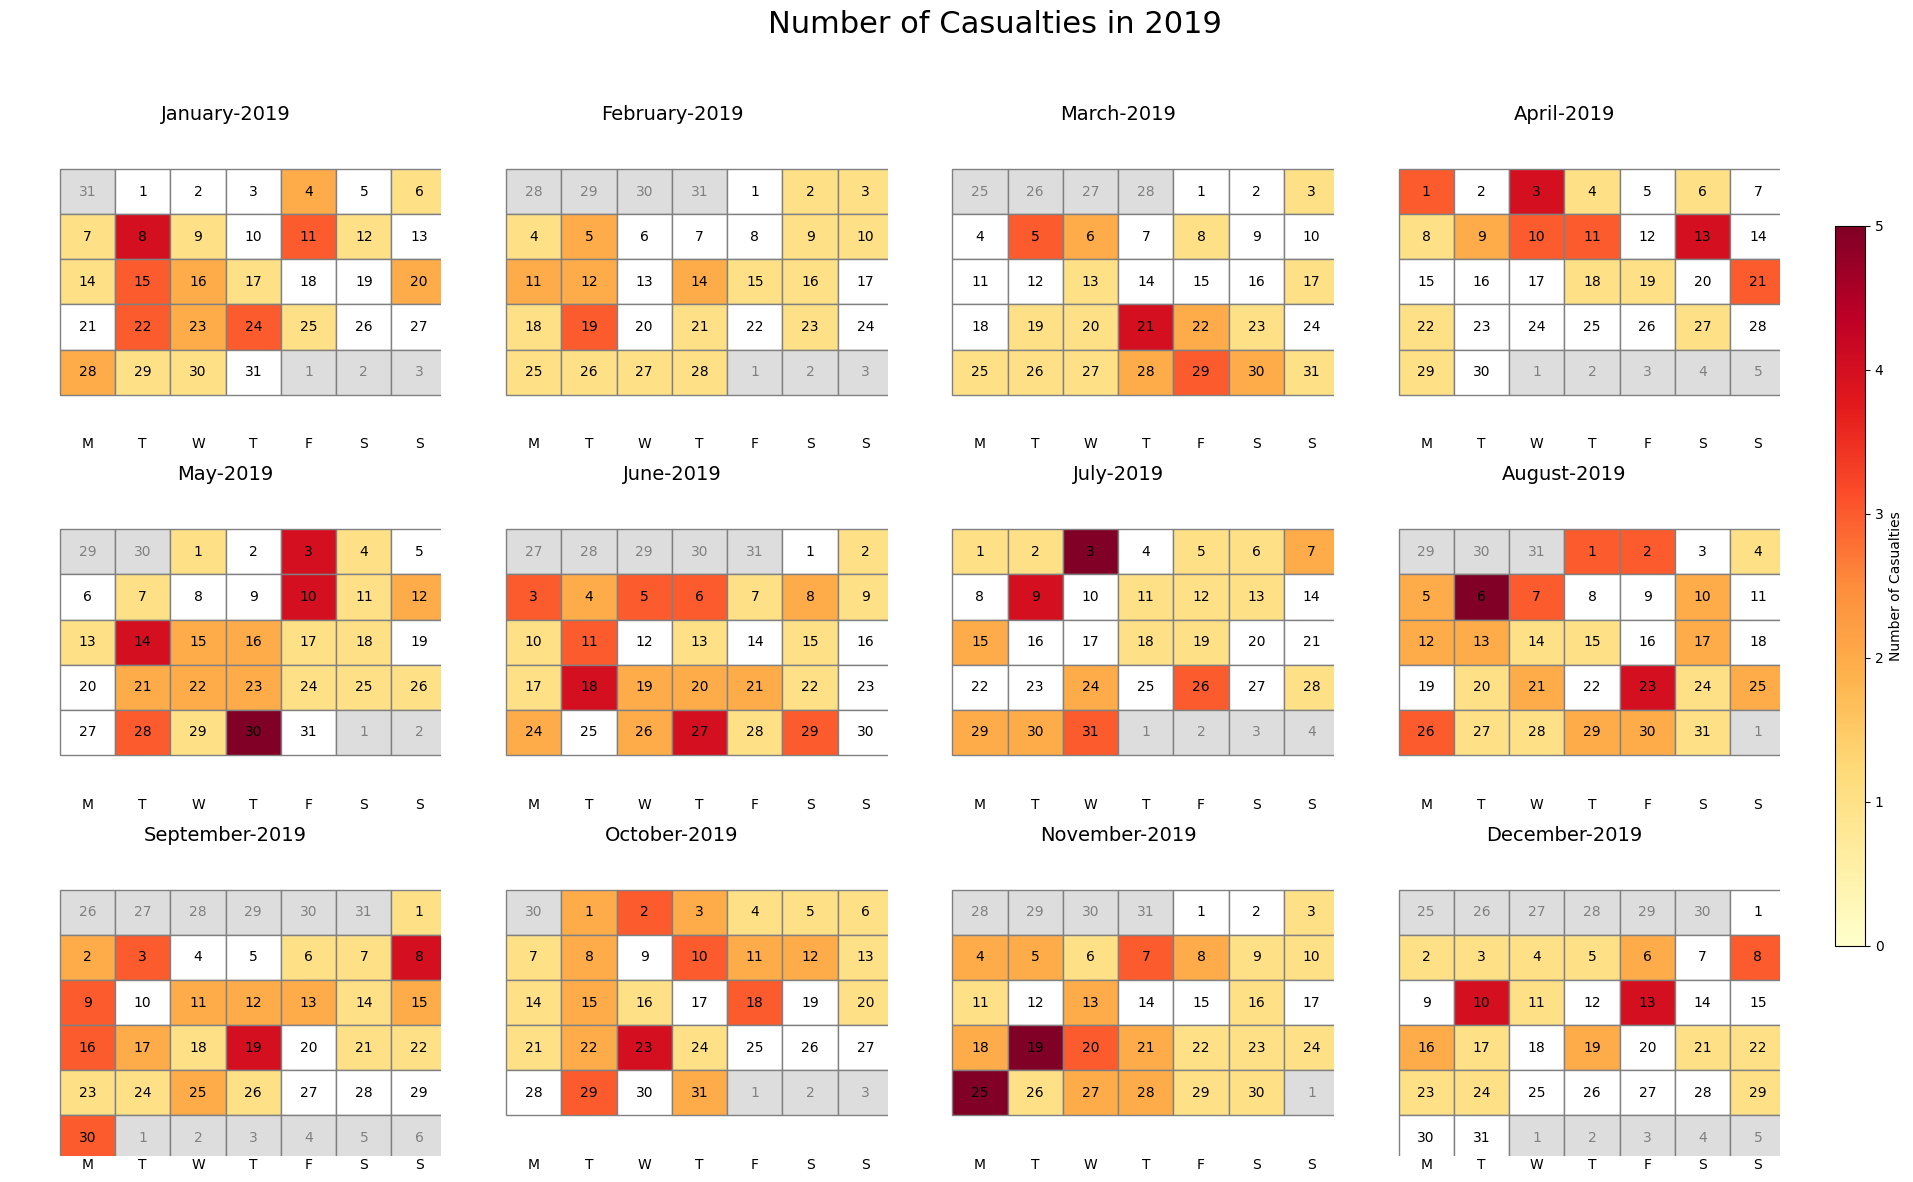

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# ====== Data Preparation ======
df = pd.read_csv('individual model_data 2016_2020 greater manchester.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date_only'] = df['date'].dt.date

# Select Year
year = 2019
df = df[pd.to_datetime(df['date_only']).dt.year == year]
daily_counts = df.groupby('date_only')['number_of_casualties'].sum()

# Create a complete date range
date_range = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31')
daily = pd.DataFrame({'date': date_range})
daily['number_of_casualties'] = daily['date'].dt.date.map(daily_counts).fillna(0).astype(int)

# ====== draw ======
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle(f'Number of Casualties in {year}', fontsize=22)

for month in range(1, 13):
    ax = axes[(month - 1) // 4, (month - 1) % 4]
    ax.set_title(calendar.month_name[month] + f'-{year}', fontsize=14)
    ax.axis('off')

   # Obtain the complete display range for this month (including the padding for the previous month and the next month)
    first_day = pd.Timestamp(year, month, 1)
    last_day = pd.Timestamp(year, month, calendar.monthrange(year, month)[1])
    start_date = first_day - pd.Timedelta(days=first_day.weekday())
    end_date = last_day + pd.Timedelta(days=6 - last_day.weekday())

    month_range = pd.date_range(start=start_date, end=end_date)

    for date in month_range:
        day = date.day
        weekday = date.weekday()
        week = (date - start_date).days // 7

        in_current_month = (date.month == month)
        casualties = daily_counts.get(date.date(), 0)

        # Color Settings
        color = (
            plt.cm.YlOrRd(casualties / 5)
            if casualties > 0 and in_current_month else
            ('white' if in_current_month else '#dddddd')
        )


        # Draw Grids
        rect = plt.Rectangle((weekday, week), 1, 1, color=color, ec='gray')
        ax.add_patch(rect)



        # Center display of the "number" digit
        text_color = 'black' if in_current_month else 'gray'
        ax.text(weekday + 0.5, week + 0.5, f"{day}",
                ha='center', va='center', fontsize=10, color=text_color)

    ax.set_xlim(-0.9, 6.9)
    ax.set_ylim(5.9, -0.9)

    # Week Indicator
    for i, dayname in enumerate(['M', 'T', 'W', 'T', 'F', 'S', 'S']):
        ax.text(i + 0.5, 6.1, dayname, ha='center', va='center', fontsize=10)

# Add color bar
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=0, vmax=5))
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
fig.colorbar(sm, cax=cbar_ax, label='Number of Casualties')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


C:\Users\18237\AppData\Local\Temp\ipykernel_14892\3360703266.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


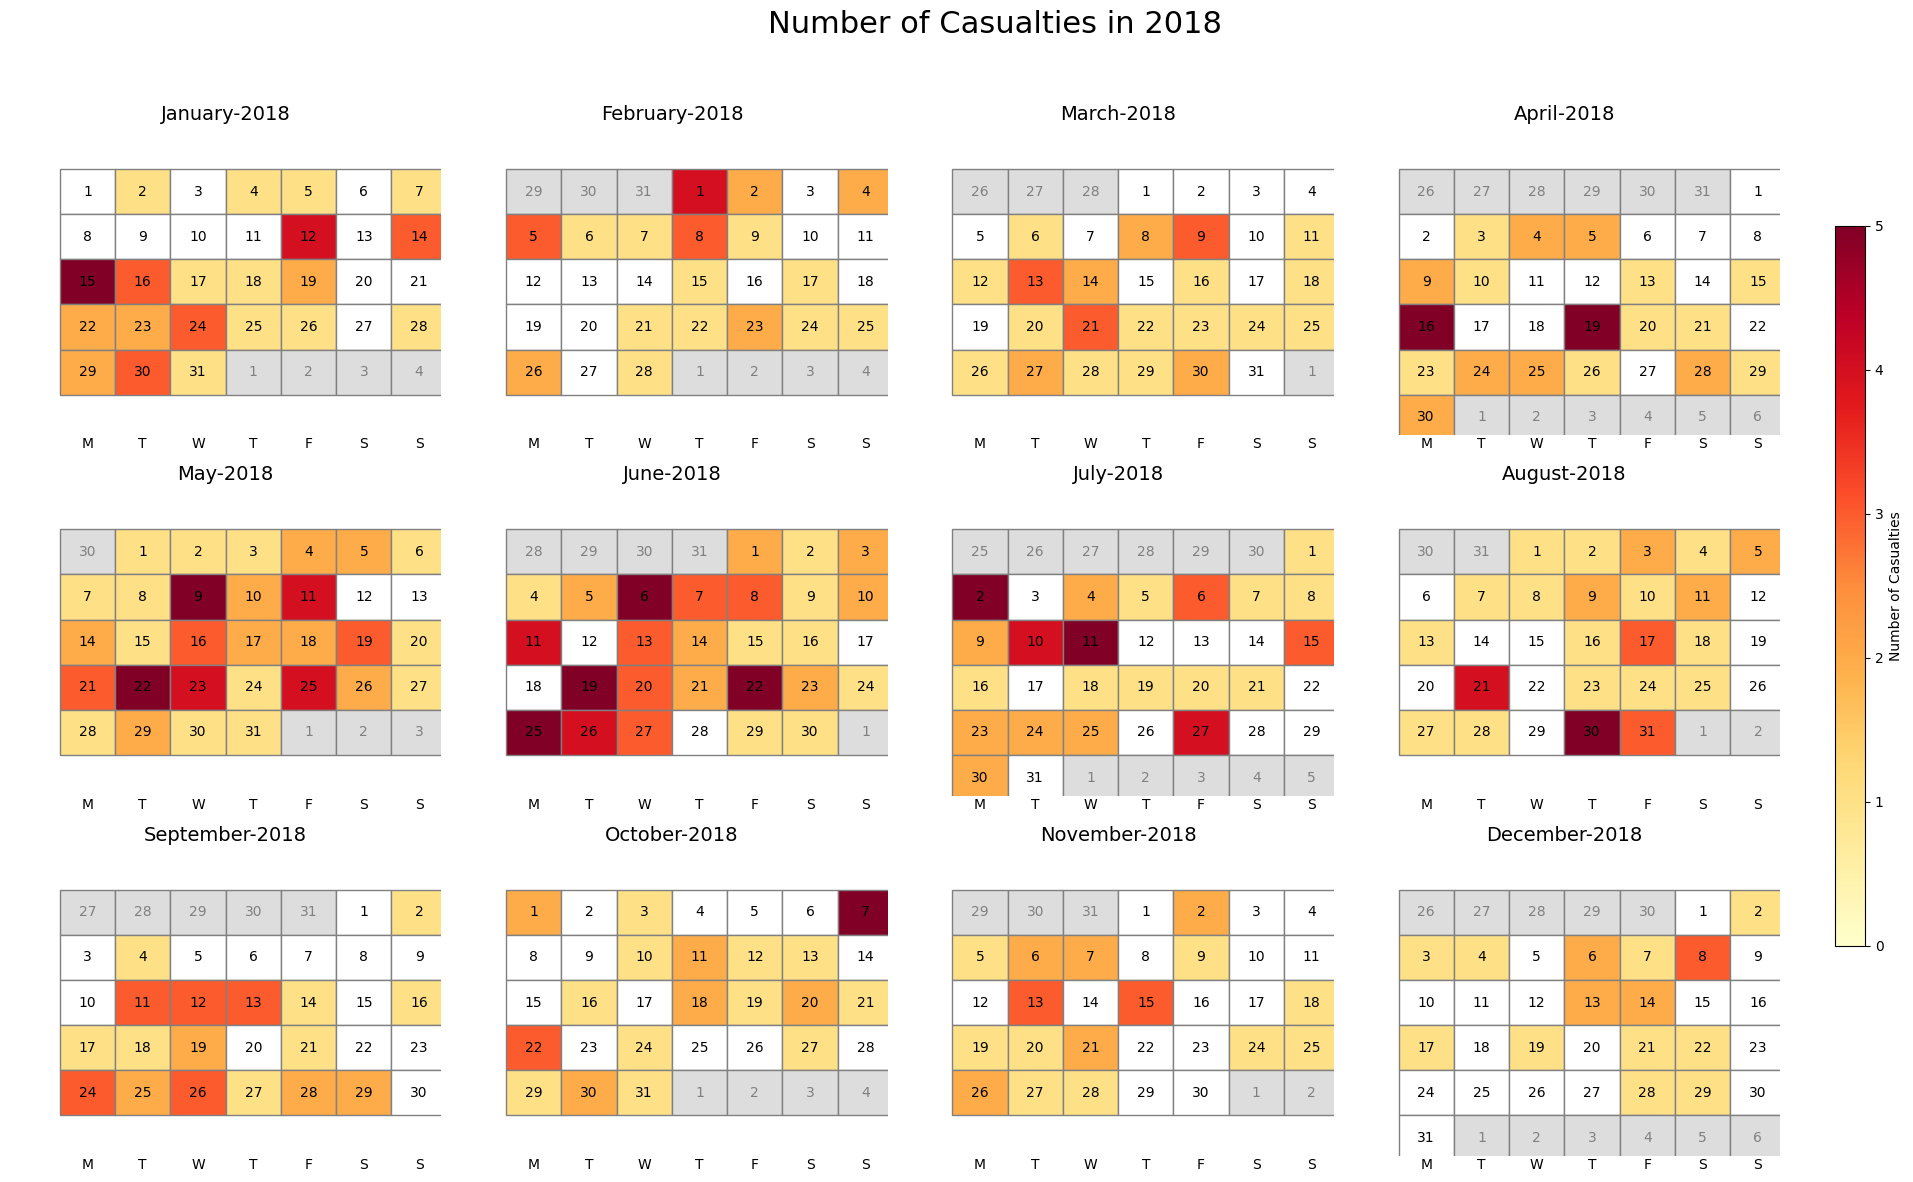

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# ====== Data Preparation ======
df = pd.read_csv('individual model_data 2016_2020 greater manchester.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date_only'] = df['date'].dt.date

# Select Year
year = 2018
df = df[pd.to_datetime(df['date_only']).dt.year == year]
daily_counts = df.groupby('date_only')['number_of_casualties'].sum()

# Create a complete date range
date_range = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31')
daily = pd.DataFrame({'date': date_range})
daily['number_of_casualties'] = daily['date'].dt.date.map(daily_counts).fillna(0).astype(int)

# ====== draw ======
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle(f'Number of Casualties in {year}', fontsize=22)

for month in range(1, 13):
    ax = axes[(month - 1) // 4, (month - 1) % 4]
    ax.set_title(calendar.month_name[month] + f'-{year}', fontsize=14)
    ax.axis('off')

   # Obtain the complete display range for this month (including the padding for the previous month and the next month)
    first_day = pd.Timestamp(year, month, 1)
    last_day = pd.Timestamp(year, month, calendar.monthrange(year, month)[1])
    start_date = first_day - pd.Timedelta(days=first_day.weekday())
    end_date = last_day + pd.Timedelta(days=6 - last_day.weekday())

    month_range = pd.date_range(start=start_date, end=end_date)

    for date in month_range:
        day = date.day
        weekday = date.weekday()
        week = (date - start_date).days // 7

        in_current_month = (date.month == month)
        casualties = daily_counts.get(date.date(), 0)

        # Color Settings
        color = (
            plt.cm.YlOrRd(casualties / 5)
            if casualties > 0 and in_current_month else
            ('white' if in_current_month else '#dddddd')
        )


        # Draw Grids
        rect = plt.Rectangle((weekday, week), 1, 1, color=color, ec='gray')
        ax.add_patch(rect)



        # Center display of the "number" digit
        text_color = 'black' if in_current_month else 'gray'
        ax.text(weekday + 0.5, week + 0.5, f"{day}",
                ha='center', va='center', fontsize=10, color=text_color)

    ax.set_xlim(-0.9, 6.9)
    ax.set_ylim(5.9, -0.9)

    # Week Indicator
    for i, dayname in enumerate(['M', 'T', 'W', 'T', 'F', 'S', 'S']):
        ax.text(i + 0.5, 6.1, dayname, ha='center', va='center', fontsize=10)

# Add color bar
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=0, vmax=5))
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
fig.colorbar(sm, cax=cbar_ax, label='Number of Casualties')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


C:\Users\18237\AppData\Local\Temp\ipykernel_14892\2935061628.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


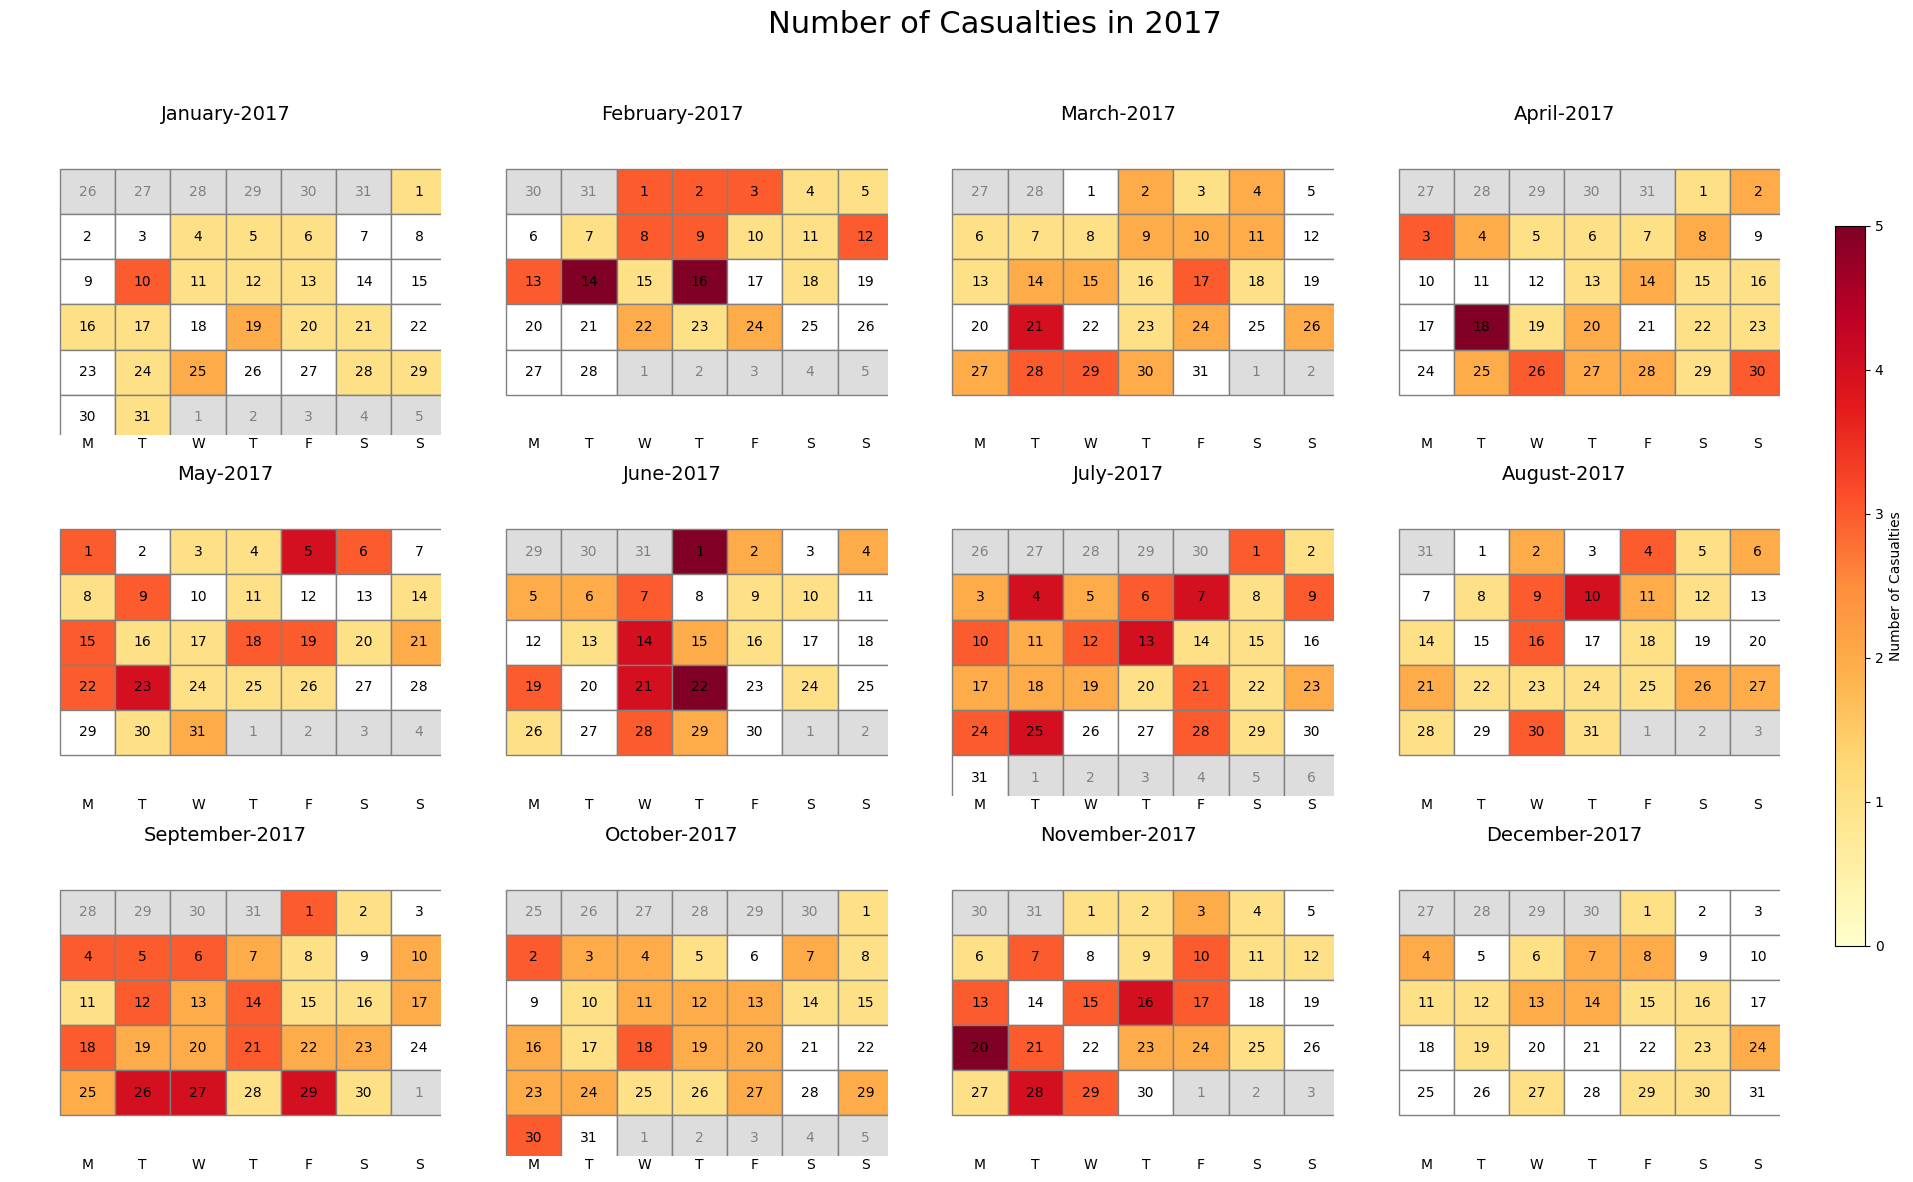

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# ====== Data Preparation ======
df = pd.read_csv('individual model_data 2016_2020 greater manchester.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date_only'] = df['date'].dt.date

# Select Year
year = 2017
df = df[pd.to_datetime(df['date_only']).dt.year == year]
daily_counts = df.groupby('date_only')['number_of_casualties'].sum()

# Create a complete date range
date_range = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31')
daily = pd.DataFrame({'date': date_range})
daily['number_of_casualties'] = daily['date'].dt.date.map(daily_counts).fillna(0).astype(int)

# ====== draw ======
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle(f'Number of Casualties in {year}', fontsize=22)

for month in range(1, 13):
    ax = axes[(month - 1) // 4, (month - 1) % 4]
    ax.set_title(calendar.month_name[month] + f'-{year}', fontsize=14)
    ax.axis('off')

   # Obtain the complete display range for this month (including the padding for the previous month and the next month)
    first_day = pd.Timestamp(year, month, 1)
    last_day = pd.Timestamp(year, month, calendar.monthrange(year, month)[1])
    start_date = first_day - pd.Timedelta(days=first_day.weekday())
    end_date = last_day + pd.Timedelta(days=6 - last_day.weekday())

    month_range = pd.date_range(start=start_date, end=end_date)

    for date in month_range:
        day = date.day
        weekday = date.weekday()
        week = (date - start_date).days // 7

        in_current_month = (date.month == month)
        casualties = daily_counts.get(date.date(), 0)

        # Color Settings
        color = (
            plt.cm.YlOrRd(casualties / 5)
            if casualties > 0 and in_current_month else
            ('white' if in_current_month else '#dddddd')
        )


        # Draw Grids
        rect = plt.Rectangle((weekday, week), 1, 1, color=color, ec='gray')
        ax.add_patch(rect)



        # Center display of the "number" digit
        text_color = 'black' if in_current_month else 'gray'
        ax.text(weekday + 0.5, week + 0.5, f"{day}",
                ha='center', va='center', fontsize=10, color=text_color)

    ax.set_xlim(-0.9, 6.9)
    ax.set_ylim(5.9, -0.9)

    # Week Indicator
    for i, dayname in enumerate(['M', 'T', 'W', 'T', 'F', 'S', 'S']):
        ax.text(i + 0.5, 6.1, dayname, ha='center', va='center', fontsize=10)

# Add color bar
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=0, vmax=5))
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
fig.colorbar(sm, cax=cbar_ax, label='Number of Casualties')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


C:\Users\18237\AppData\Local\Temp\ipykernel_14892\4095138432.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


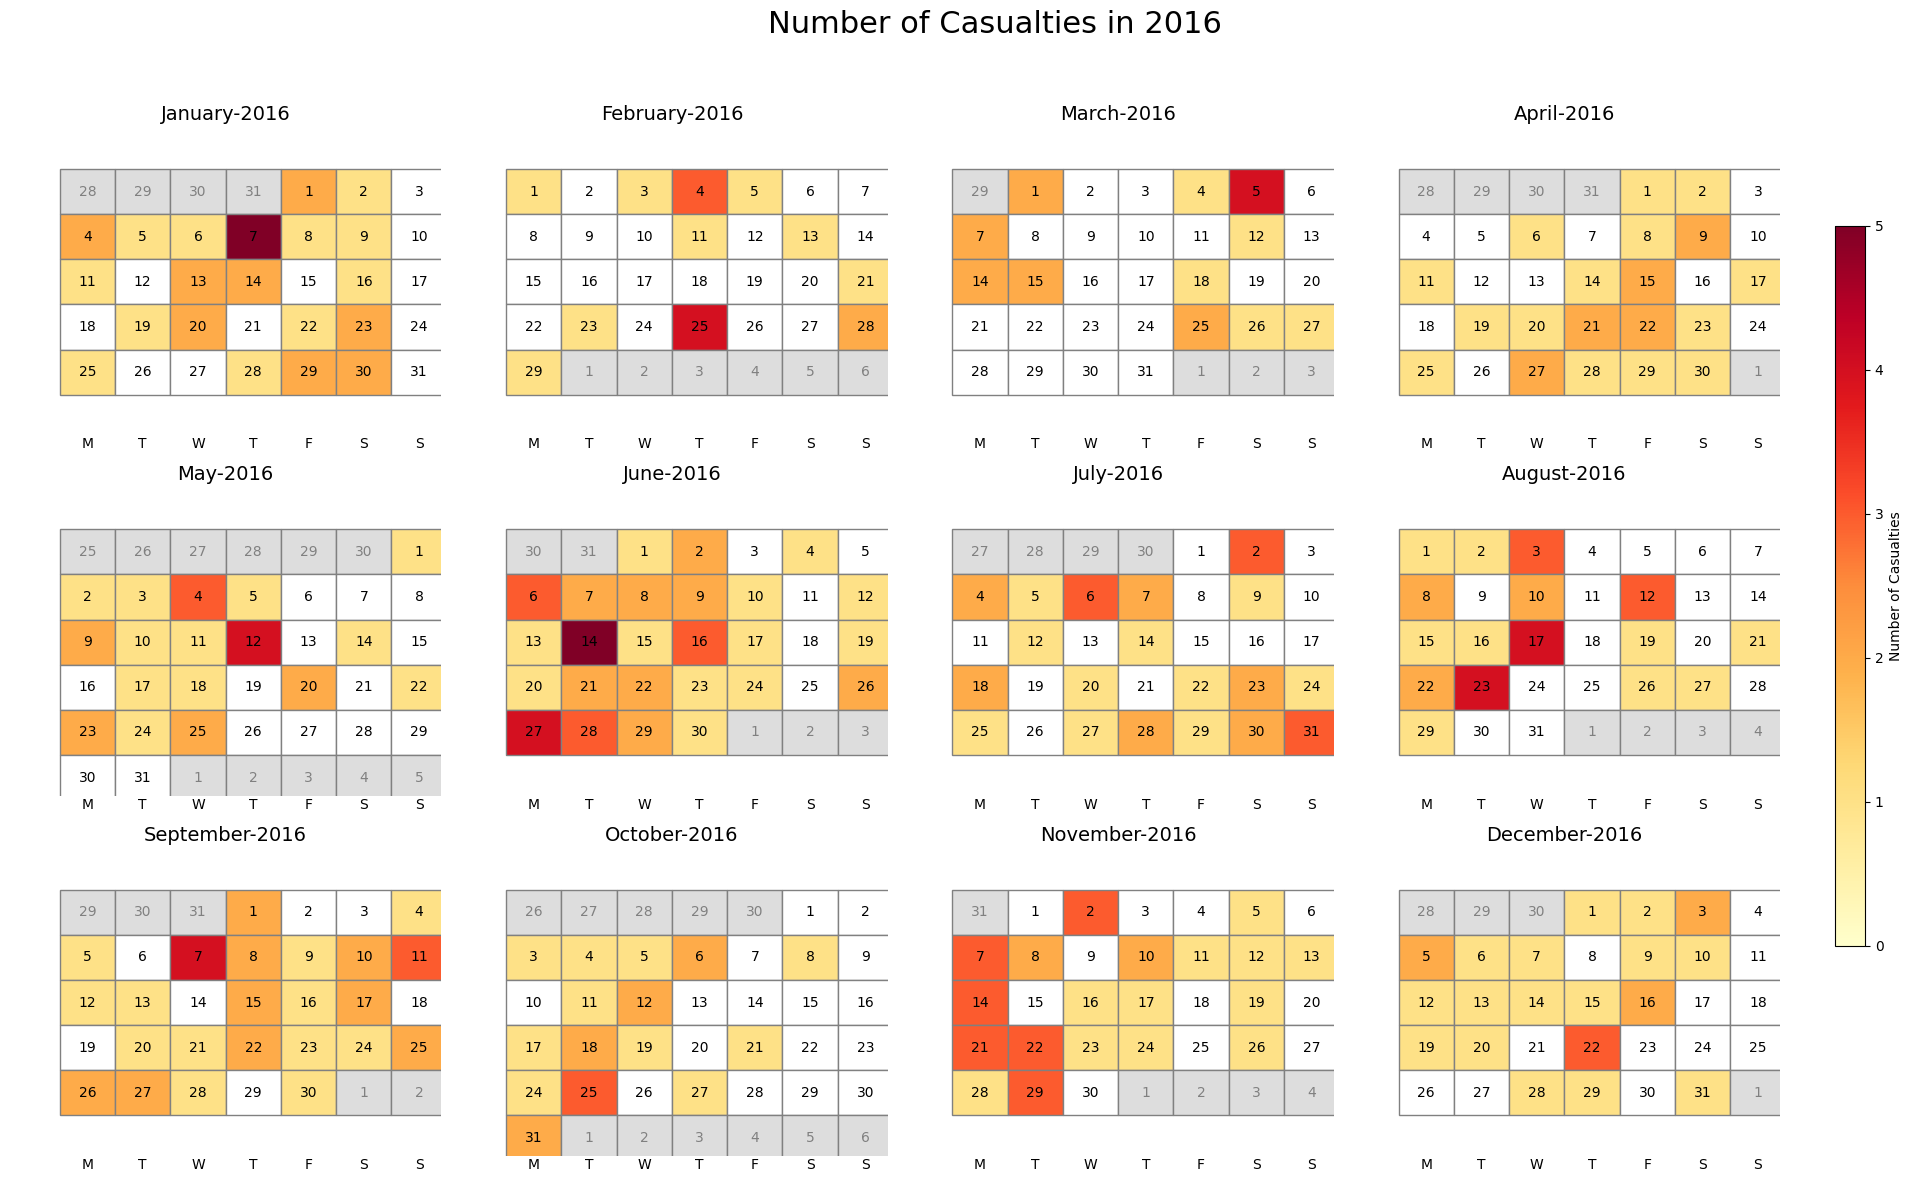

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# ====== Data Preparation ======
df = pd.read_csv('individual model_data 2016_2020 greater manchester.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date_only'] = df['date'].dt.date

# Select Year
year = 2016
df = df[pd.to_datetime(df['date_only']).dt.year == year]
daily_counts = df.groupby('date_only')['number_of_casualties'].sum()

# Create a complete date range
date_range = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31')
daily = pd.DataFrame({'date': date_range})
daily['number_of_casualties'] = daily['date'].dt.date.map(daily_counts).fillna(0).astype(int)

# ====== draw ======
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle(f'Number of Casualties in {year}', fontsize=22)

for month in range(1, 13):
    ax = axes[(month - 1) // 4, (month - 1) % 4]
    ax.set_title(calendar.month_name[month] + f'-{year}', fontsize=14)
    ax.axis('off')

   # Obtain the complete display range for this month (including the padding for the previous month and the next month)
    first_day = pd.Timestamp(year, month, 1)
    last_day = pd.Timestamp(year, month, calendar.monthrange(year, month)[1])
    start_date = first_day - pd.Timedelta(days=first_day.weekday())
    end_date = last_day + pd.Timedelta(days=6 - last_day.weekday())

    month_range = pd.date_range(start=start_date, end=end_date)

    for date in month_range:
        day = date.day
        weekday = date.weekday()
        week = (date - start_date).days // 7

        in_current_month = (date.month == month)
        casualties = daily_counts.get(date.date(), 0)

        # Color Settings
        color = (
            plt.cm.YlOrRd(casualties / 5)
            if casualties > 0 and in_current_month else
            ('white' if in_current_month else '#dddddd')
        )


        # Draw Grids
        rect = plt.Rectangle((weekday, week), 1, 1, color=color, ec='gray')
        ax.add_patch(rect)



        # Center display of the "number" digit
        text_color = 'black' if in_current_month else 'gray'
        ax.text(weekday + 0.5, week + 0.5, f"{day}",
                ha='center', va='center', fontsize=10, color=text_color)

    ax.set_xlim(-0.9, 6.9)
    ax.set_ylim(5.9, -0.9)

    # Week Indicator
    for i, dayname in enumerate(['M', 'T', 'W', 'T', 'F', 'S', 'S']):
        ax.text(i + 0.5, 6.1, dayname, ha='center', va='center', fontsize=10)

# Add color bar
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=0, vmax=5))
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
fig.colorbar(sm, cax=cbar_ax, label='Number of Casualties')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


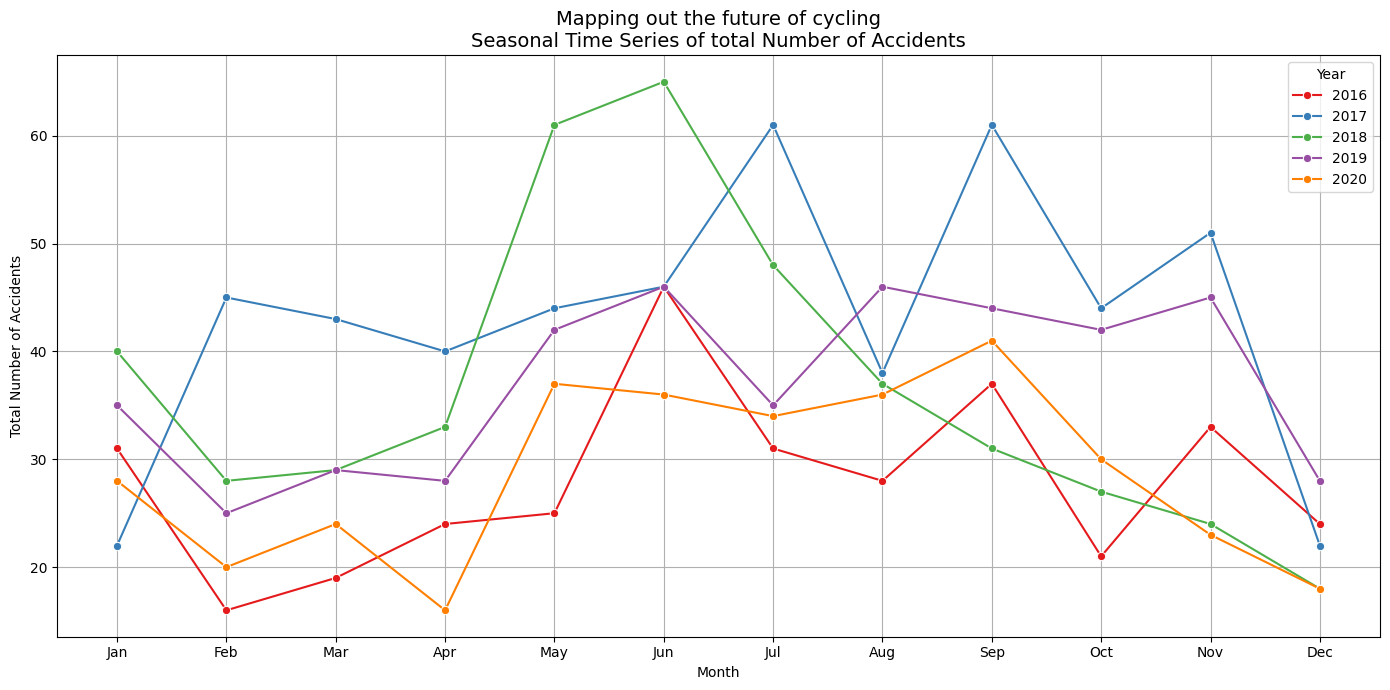

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data file
file_path = "individual model_data 2016_2020 greater manchester.csv"
df = pd.read_csv(file_path)

# Convert Date Format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter 2016 - 2020
df_filtered = df[df['year'].between(2016, 2020)]

# Extract the month# Extract the month
df_filtered['month'] = df_filtered['date'].dt.month_name().str[:3]
df_filtered['month_order'] = df_filtered['date'].dt.month

# Count the number of accidents per month
accident_counts = (
    df_filtered.groupby(['year', 'month', 'month_order'])
    .size()
    .reset_index(name='total_accidents')
)
accident_counts.sort_values(by='month_order', inplace=True)

# Custom High-Contrast Color Palette 
color_palette = {
    2016: "#E41A1C",  # Red
    2017: "#377EB8",  # Blue
    2018: "#4DAF4A",  # Green
    2019: "#984EA3",  # Purple
    2020: "#FF7F00"   # Orange
}

# Drawing
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=accident_counts,
    x='month',
    y='total_accidents',
    hue='year',
    palette=color_palette,
    marker="o"
)
plt.title("Mapping out the future of cycling\nSeasonal Time Series of total Number of Accidents", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Number of Accidents")
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()


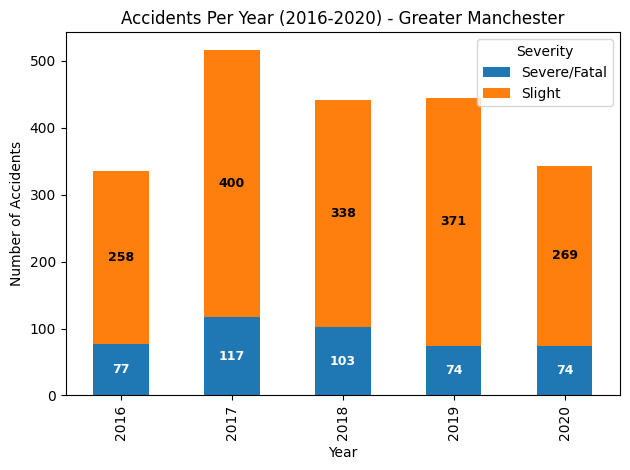

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Reading CSV Files
file_path = "individual model_data 2016_2020 greater manchester.csv"
df = pd.read_csv(file_path)

# Keep Only the Required Columns
df_filtered = df[['year', 'slightsevere']]

# Statistics of accidents of different severity by year
accident_counts = df_filtered.groupby(['year', 'slightsevere']).size().unstack(fill_value=0)

# Sort by Year
accident_counts = accident_counts.sort_index()

# 确保列顺序
if 'Severe/Fatal' in accident_counts.columns and 'Slight' in accident_counts.columns:
    accident_counts = accident_counts[['Severe/Fatal', 'Slight']]

# 绘制堆叠柱状图
ax = accident_counts.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])

# 添加每部分的数字标签
for i, (year, row) in enumerate(accident_counts.iterrows()):
    severe = row['Severe/Fatal']
    slight = row['Slight']
    total = severe + slight

    # 蓝色部分（底部）
    ax.text(i, severe / 2, f"{int(severe)}", ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    # 橙色部分（上半部分）
    ax.text(i, severe + slight / 2, f"{int(slight)}", ha='center', va='center', color='black', fontsize=9, fontweight='bold')

   

# 图表样式
plt.title("Accidents Per Year (2016-2020) - Greater Manchester")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity")
plt.tight_layout()

# 显示图表
plt.show()
